# Image Classification Mini Task: CNN vs Vision Transformer

**Task**: Classify FashionMNIST images (10 classes) using:
1. A CNN-based model
2. A Vision Transformer (ViT)

**Key skills demonstrated**:
- Custom Dataset implementation
- CNN architecture design
- Vision Transformer from scratch
- Proper training & evaluation pipeline

In [1]:
# Install wandb if needed (uncomment the line below)
# !pip install wandb

import wandb

# Login to wandb (only needed once per machine)
# This will prompt you for your API key the first time
wandb.login()

wandb: WARNING Failed to create global config settings in: /Users/larryjin/.config/wandb. Settings will not be persisted.
wandb: Currently logged in as: lonelysun1990 (lonelysun1990-stanford-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration (with MPS support for Apple Silicon)
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: mps


## Step 1: Load FashionMNIST Data

In [3]:
# FashionMNIST class labels
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download and load raw data
transform = transforms.Compose([transforms.ToTensor()])

train_dataset_raw = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset_raw = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

print(f"Training samples: {len(train_dataset_raw)}")
print(f"Test samples: {len(test_dataset_raw)}")
print(f"Image shape: {train_dataset_raw[0][0].shape}")  # (C, H, W)
print(f"Number of classes: {len(CLASS_NAMES)}")

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


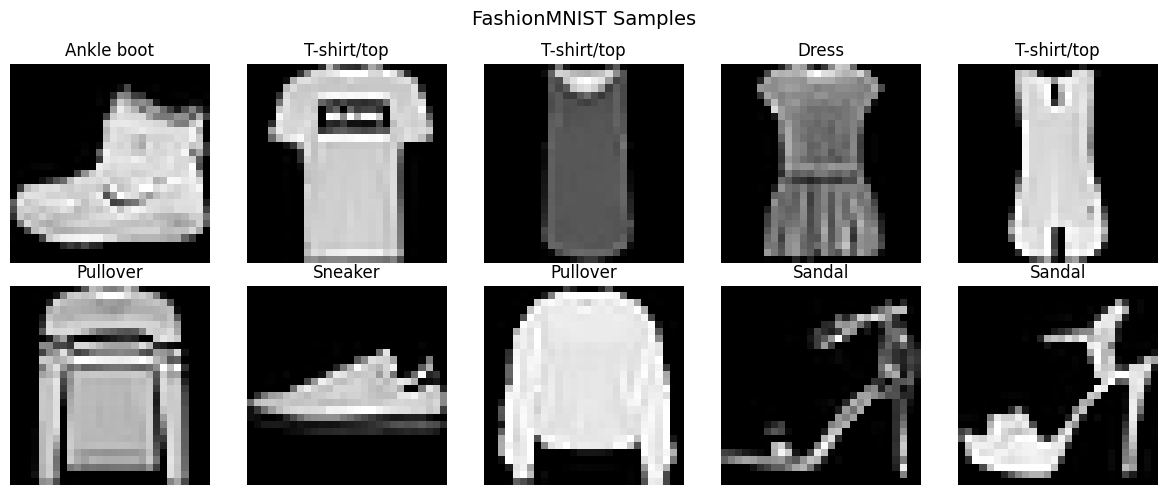

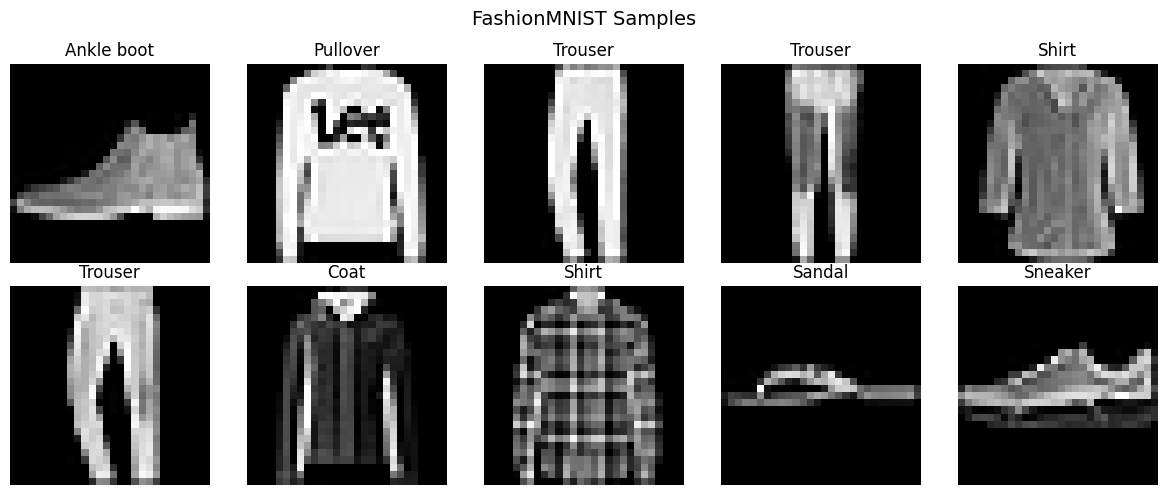

In [4]:
# Visualize some samples
def visualize_sampels(dataset):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        img, label = dataset[i]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(CLASS_NAMES[label])
        ax.axis('off')
    plt.suptitle('FashionMNIST Samples', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_sampels(train_dataset_raw)
visualize_sampels(test_dataset_raw)

## Step 2: Custom Dataset Implementation

Two approaches shown:
1. **Custom Dataset class** (most flexible, interview favorite)
2. **TensorDataset** (quick and simple)

In [5]:
# Approach 1: Custom Dataset Class (Interview favorite - shows you understand PyTorch)
class FashionMNISTCustomDataset(Dataset):
    """
    Custom Dataset for FashionMNIST.
    
    This demonstrates:
    - How to implement __len__ and __getitem__
    - How to apply transforms
    - How to handle data augmentation
    """
    def __init__(self, images, labels, transform=None, augment=False):
        """
        Args:
            images: numpy array of shape (N, H, W) or (N, C, H, W)
            labels: numpy array of shape (N,)
            transform: optional transforms to apply
            augment: whether to apply data augmentation
        """
        # Store as tensors
        if isinstance(images, np.ndarray):
            self.images = torch.tensor(images, dtype=torch.float32)
        else:
            self.images = images.float()
            
        if isinstance(labels, np.ndarray):
            self.labels = torch.tensor(labels, dtype=torch.long)
        else:
            self.labels = labels.long()
        
        # Add channel dimension if needed: (N, H, W) -> (N, 1, H, W)
        if self.images.dim() == 3:
            self.images = self.images.unsqueeze(1)
        
        # Normalize to [0, 1] if not already
        if self.images.max() > 1:
            self.images = self.images / 255.0
            
        self.transform = transform
        self.augment = augment
        
    def __len__(self):
        """Return total number of samples."""
        return len(self.labels)
    
    def __getitem__(self, idx):
        """Return one sample (image, label) at index idx."""
        image = self.images[idx]
        label = self.labels[idx]
        
        # Apply augmentation during training
        if self.augment:
            # Random horizontal flip
            if torch.rand(1) > 0.5:
                image = torch.flip(image, dims=[-1])
            # Random rotation (small)
            # Add more augmentations as needed
        
        # Apply additional transforms if provided
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
    def get_image_shape(self):
        """Utility method to get image dimensions."""
        return self.images[0].shape

# Test the custom dataset
print("Custom Dataset Implementation Test:")
sample_images = torch.stack([train_dataset_raw[i][0] for i in range(100)])
sample_labels = torch.tensor([train_dataset_raw[i][1] for i in range(100)])
custom_dataset = FashionMNISTCustomDataset(sample_images, sample_labels)
print(f"Dataset length: {len(custom_dataset)}")
print(f"Sample shape: {custom_dataset[0][0].shape}")

Custom Dataset Implementation Test:
Dataset length: 100
Sample shape: torch.Size([1, 28, 28])


In [6]:
# Approach 2: TensorDataset (simpler, but less flexible)
# Convert entire dataset to tensors first
def create_tensor_dataset(pytorch_dataset):
    """Convert a PyTorch dataset to TensorDataset."""
    images = torch.stack([pytorch_dataset[i][0] for i in range(len(pytorch_dataset))])
    labels = torch.tensor([pytorch_dataset[i][1] for i in range(len(pytorch_dataset))])
    return TensorDataset(images, labels)

# For this notebook, we'll use the Custom Dataset approach for training
# Extract all data as numpy/tensors for our custom dataset
train_images = torch.stack([train_dataset_raw[i][0] for i in range(len(train_dataset_raw))])
train_labels = torch.tensor([train_dataset_raw[i][1] for i in range(len(train_dataset_raw))])
test_images = torch.stack([test_dataset_raw[i][0] for i in range(len(test_dataset_raw))])
test_labels = torch.tensor([test_dataset_raw[i][1] for i in range(len(test_dataset_raw))])

print(f"Train images shape: {train_images.shape}")  # (60000, 1, 28, 28)
print(f"Test images shape: {test_images.shape}")    # (10000, 1, 28, 28)

Train images shape: torch.Size([60000, 1, 28, 28])
Test images shape: torch.Size([10000, 1, 28, 28])


In [7]:
# Create datasets using our custom class
train_dataset = FashionMNISTCustomDataset(train_images, train_labels, augment=True)
test_dataset = FashionMNISTCustomDataset(test_images, test_labels, augment=False)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 938
Test batches: 157


## Step 3: Model 1 - CNN Classifier

Classic CNN architecture for image classification.

In [8]:
class CNNClassifier(nn.Module):
    """
    CNN for image classification.
    
    Architecture:
    - Conv blocks with BatchNorm and MaxPool
    - Global Average Pooling
    - Fully connected classifier
    
    Input: (batch, 1, 28, 28)
    Output: (batch, num_classes)
    """
    def __init__(self, num_classes=10, in_channels=1):
        super().__init__()
        
        # Convolutional blocks
        self.conv_blocks = nn.Sequential(
            # Block 1: 28x28 -> 14x14
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14
            nn.Dropout2d(0.25),
            
            # Block 2: 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 -> 7
            nn.Dropout2d(0.25),
            
            # Block 3: 7x7 -> 3x3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7 -> 3
        )
        
        # Global Average Pooling + Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # -> (batch, 128, 1, 1)
            nn.Flatten(),              # -> (batch, 128)
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.classifier(x)
        return x

# Test CNN
cnn_model = CNNClassifier(num_classes=10).to(device)
dummy_input = torch.randn(2, 1, 28, 28).to(device)
dummy_output = cnn_model(dummy_input)
print(f"CNN Input shape: {dummy_input.shape}")
print(f"CNN Output shape: {dummy_output.shape}")
print(f"CNN Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

CNN Input shape: torch.Size([2, 1, 28, 28])
CNN Output shape: torch.Size([2, 10])
CNN Parameters: 140,778


## Step 4: Model 2 - Vision Transformer (ViT)

Key idea: Split image into patches, treat each patch as a "token", apply Transformer.

In [9]:
class PatchEmbedding(nn.Module):
    """
    Split image into patches and project to embedding dimension.
    
    For a 28x28 image with patch_size=7:
    - Number of patches = (28/7) * (28/7) = 16 patches
    - Each patch: 7x7 = 49 pixels
    """
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 16 for 28x28 with 7x7 patches
        
        # Linear projection of flattened patches
        # Can also use Conv2d with kernel_size=patch_size, stride=patch_size
        self.projection = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, stride=patch_size
        )
    
    def forward(self, x):
        # x: (batch, channels, H, W)
        # After conv: (batch, embed_dim, num_patches_h, num_patches_w)
        x = self.projection(x)
        # Flatten spatial dims: (batch, embed_dim, num_patches)
        x = x.flatten(2)
        # Transpose: (batch, num_patches, embed_dim)
        x = x.transpose(1, 2)
        return x


class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) for image classification.
    
    Architecture:
    1. Split image into patches
    2. Linear embedding of patches
    3. Add positional encoding + [CLS] token
    4. Transformer encoder
    5. MLP head on [CLS] token for classification
    """
    def __init__(self, img_size=28, patch_size=7, in_channels=1, num_classes=10,
                 embed_dim=128, num_heads=4, num_layers=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        
        self.num_patches = (img_size // patch_size) ** 2
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        
        # Learnable [CLS] token - prepended to patch sequence
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        # Positional embedding (learnable)
        # +1 for [CLS] token
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        
        self.dropout = nn.Dropout(dropout)
        
        # Transformer encoder (using PyTorch's built-in)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN (more stable)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Final layer norm
        self.norm = nn.LayerNorm(embed_dim)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # 1. Patch embedding: (batch, num_patches, embed_dim)
        x = self.patch_embed(x)
        
        # 2. Prepend [CLS] token: (batch, num_patches + 1, embed_dim)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        
        # 3. Add positional embedding
        x = x + self.pos_embed
        x = self.dropout(x)
        
        # 4. Transformer encoder
        x = self.transformer(x)
        x = self.norm(x)
        
        # 5. Extract [CLS] token and classify
        cls_output = x[:, 0]  # (batch, embed_dim)
        logits = self.classifier(cls_output)
        
        return logits

# Test ViT
vit_model = VisionTransformer(
    img_size=28, patch_size=7, in_channels=1, num_classes=10,
    embed_dim=128, num_heads=4, num_layers=4
).to(device)

dummy_output = vit_model(dummy_input)
print(f"ViT Input shape: {dummy_input.shape}")
print(f"ViT Output shape: {dummy_output.shape}")
print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")

ViT Input shape: torch.Size([2, 1, 28, 28])
ViT Output shape: torch.Size([2, 10])
ViT Parameters: 819,850


/Users/larryjin/Documents/Programs/anaconda3/envs/prototype/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Step 5: Training Function

Reusable training function for both models.

In [10]:
def train_model(model, train_loader, test_loader, num_epochs=10, lr=1e-3, device='cpu', 
                model_name='model', use_wandb=True):
    """
    Train a model with optional wandb logging.
    
    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        num_epochs: Number of training epochs
        lr: Learning rate
        device: Device to train on ('cpu', 'cuda', 'mps')
        model_name: Name of the model (for wandb run name)
        use_wandb: Whether to log metrics to wandb
    """
    # Initialize wandb run
    if use_wandb:
        wandb.init(
            project="image-classification",  # Change to your project name
            name=f"{model_name}-run",
            config={
                "model": model_name,
                "epochs": num_epochs,
                "learning_rate": lr,
                "optimizer": "Adam",
                "scheduler": "CosineAnnealingLR",
                "device": str(device),
            }
        )
        # Watch the model to log gradients and parameters (optional)
        wandb.watch(model, log="all", log_freq=100)
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)
    
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        scheduler.step()
        
        # Evaluation phase
        model.eval()
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        # Record history
        train_loss_avg = train_loss / train_total
        train_acc = 100. * train_correct / train_total
        test_acc = 100. * test_correct / test_total
        
        history['train_loss'].append(train_loss_avg)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        # Log to wandb
        if use_wandb:
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss_avg,
                "train_acc": train_acc,
                "test_acc": test_acc,
                "learning_rate": scheduler.get_last_lr()[0]
            })
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss_avg:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Test Acc: {test_acc:.2f}%")
    
    # Finish wandb run
    if use_wandb:
        wandb.finish()
    
    return history

## Step 6: Train CNN Model

In [11]:
print("=" * 60)
print("Training CNN Model")
print("=" * 60)

cnn_model = CNNClassifier(num_classes=10).to(device)
cnn_history = train_model(cnn_model, train_loader, test_loader, 
                          num_epochs=10, lr=1e-3, device=device, 
                          model_name="CNN", use_wandb=True)

print(f"\nCNN Final Test Accuracy: {cnn_history['test_acc'][-1]:.2f}%")

Training CNN Model


Epoch [2/10] Train Loss: 0.4828 | Train Acc: 82.59% | Test Acc: 86.29%
Epoch [4/10] Train Loss: 0.3722 | Train Acc: 86.94% | Test Acc: 89.25%
Epoch [6/10] Train Loss: 0.3171 | Train Acc: 88.76% | Test Acc: 90.31%
Epoch [8/10] Train Loss: 0.2858 | Train Acc: 90.00% | Test Acc: 91.26%


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch [10/10] Train Loss: 0.2685 | Train Acc: 90.61% | Test Acc: 91.39%


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,█▇▇▆▅▃▂▂▁▁
test_acc,▁▄▅▆▇▇▇███
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
learning_rate,0
test_acc,91.39
train_acc,90.61333
train_loss,0.26849



CNN Final Test Accuracy: 91.39%


## Step 7: Train Vision Transformer

In [12]:
print("=" * 60)
print("Training Vision Transformer")
print("=" * 60)

vit_model = VisionTransformer(
    img_size=28, patch_size=7, in_channels=1, num_classes=10,
    embed_dim=128, num_heads=4, num_layers=4
).to(device)

# ViT typically needs lower learning rate
vit_history = train_model(vit_model, train_loader, test_loader, 
                          num_epochs=10, lr=3e-4, device=device,
                          model_name="ViT", use_wandb=True)

print(f"\nViT Final Test Accuracy: {vit_history['test_acc'][-1]:.2f}%")

Training Vision Transformer


/Users/larryjin/Documents/Programs/anaconda3/envs/prototype/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [2/10] Train Loss: 0.5537 | Train Acc: 79.64% | Test Acc: 82.80%
Epoch [4/10] Train Loss: 0.4419 | Train Acc: 83.80% | Test Acc: 84.27%
Epoch [6/10] Train Loss: 0.3945 | Train Acc: 85.40% | Test Acc: 86.13%
Epoch [8/10] Train Loss: 0.3692 | Train Acc: 86.30% | Test Acc: 86.65%


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch [10/10] Train Loss: 0.3545 | Train Acc: 86.94% | Test Acc: 87.10%


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,█▇▇▆▅▃▂▂▁▁
test_acc,▁▄▅▆▆▇████
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
learning_rate,0
test_acc,87.1
train_acc,86.94167
train_loss,0.3545



ViT Final Test Accuracy: 87.10%


## Step 8: Compare Results

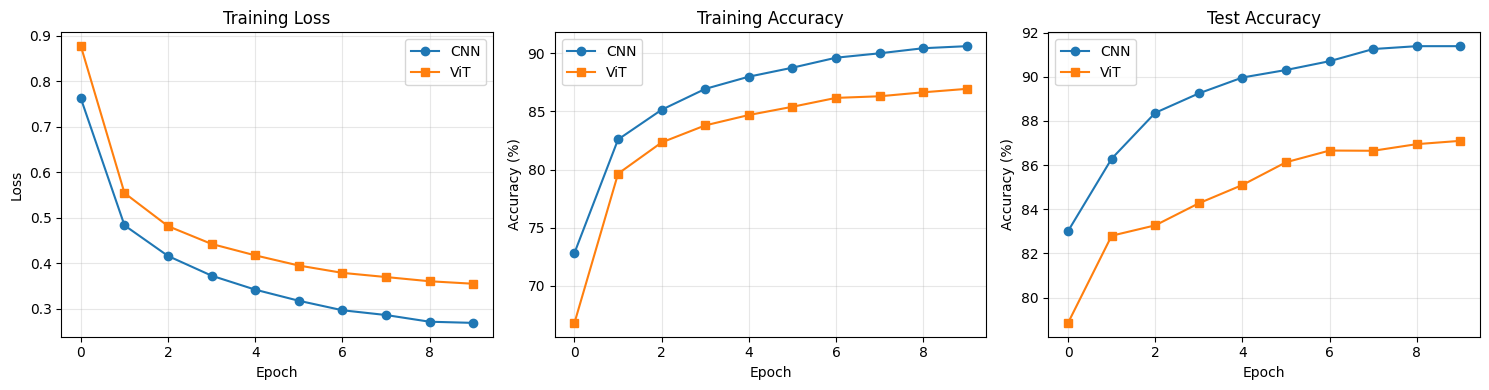


MODEL COMPARISON SUMMARY
Model                Parameters  Final Test Acc
------------------------------------------------------------
CNN                     140,778          91.39%
ViT                     819,850          87.10%


In [14]:
# Plot training curves comparison
def plot_training_curves(results):
    """
    Plot training curves for multiple models.
    
    Args:
        results: List of tuples, each containing (history, model_name)
                 where history is a dict with 'train_loss', 'train_acc', 'test_acc'
    """
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']  # Different markers for each model
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, (history, name) in enumerate(results):
        marker = markers[i % len(markers)]
        
        # Training Loss
        axes[0].plot(history['train_loss'], label=name, marker=marker)
        # Training Accuracy
        axes[1].plot(history['train_acc'], label=name, marker=marker)
        # Test Accuracy
        axes[2].plot(history['test_acc'], label=name, marker=marker)
    
    # Configure axes
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy (%)')
    axes[2].set_title('Test Accuracy')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_model_summary(models_info):
    """
    Print a summary table for multiple models.
    
    Args:
        models_info: List of tuples, each containing (model, history, model_name)
    """
    print("\n" + "=" * 60)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 60)
    print(f"{'Model':<15} {'Parameters':>15} {'Final Test Acc':>15}")
    print("-" * 60)
    for model, history, name in models_info:
        params = sum(p.numel() for p in model.parameters())
        test_acc = history['test_acc'][-1]
        print(f"{name:<15} {params:>15,} {test_acc:>14.2f}%")
    print("=" * 60)

# Create list of results for plotting
history_results = [
    (cnn_history, 'CNN'),
    (vit_history, 'ViT')
]
plot_training_curves(history_results)

# Summary table
models_info = [
    (cnn_model, cnn_history, 'CNN'),
    (vit_model, vit_history, 'ViT')
]
print_model_summary(models_info)

## Step 9: Detailed Evaluation

In [13]:
def get_predictions(model, dataloader, device):
    """Get all predictions and labels from a dataloader."""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_labels), np.array(all_preds)

# Get predictions from both models
cnn_labels, cnn_preds = get_predictions(cnn_model, test_loader, device)
vit_labels, vit_preds = get_predictions(vit_model, test_loader, device)

# Classification report for CNN
print("CNN Classification Report:")
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES))

CNN Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.90      0.88      0.89      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.86      0.89      0.87      1000
      Sandal       0.99      0.96      0.98      1000
       Shirt       0.75      0.74      0.74      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [14]:
# Classification report for ViT
print("ViT Classification Report:")
print(classification_report(vit_labels, vit_preds, target_names=CLASS_NAMES))

ViT Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.83      0.83      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.79      0.78      0.78      1000
       Dress       0.85      0.90      0.87      1000
        Coat       0.76      0.81      0.78      1000
      Sandal       0.98      0.93      0.95      1000
       Shirt       0.70      0.64      0.67      1000
     Sneaker       0.91      0.95      0.93      1000
         Bag       0.97      0.96      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



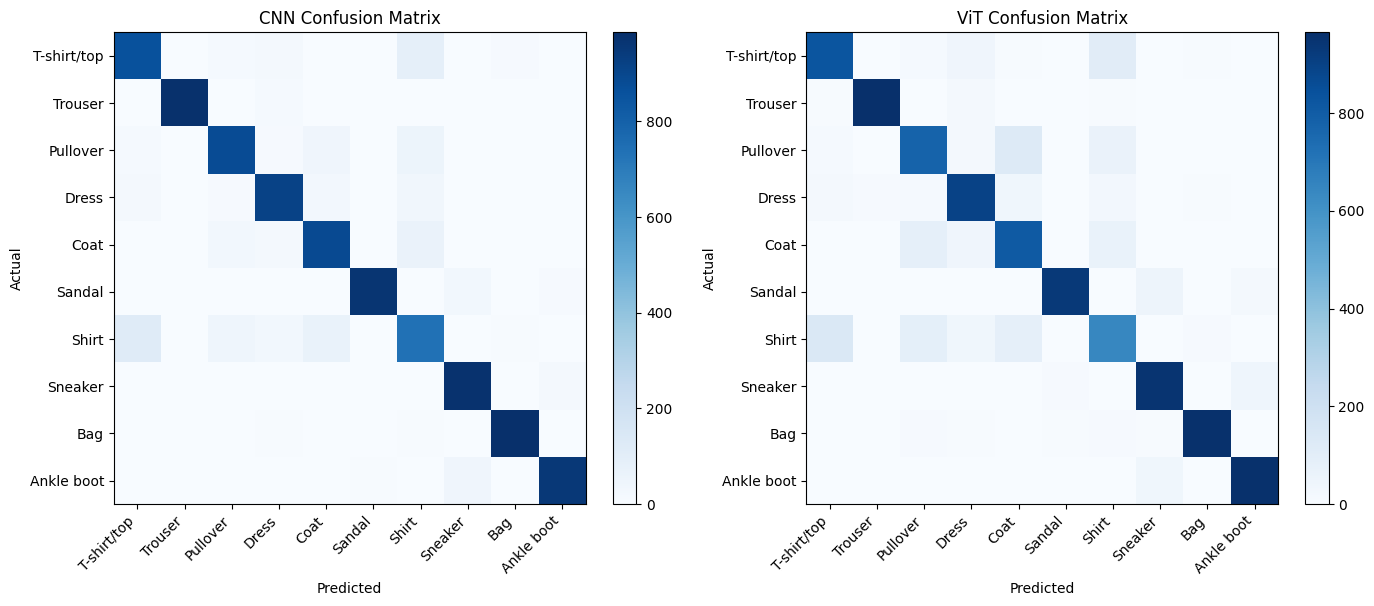

In [16]:
def plot_confusion_matrices(results):
    """
    Plot confusion matrices for multiple models.
    
    Args:
        results: List of tuples, each containing (labels, preds, model_name)
    """
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
    
    # Handle single model case (axes won't be iterable)
    if n_models == 1:
        axes = [axes]

    for ax, (labels, preds, title) in zip(axes, results):
        cm = confusion_matrix(labels, preds)
        im = ax.imshow(cm, cmap='Blues')
        
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{title} Confusion Matrix')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.show()

# Create list of results for plotting
model_results = [
    (cnn_labels, cnn_preds, 'CNN'),
    (vit_labels, vit_preds, 'ViT')
]
plot_confusion_matrices(model_results)

## Summary & Key Takeaways

### CNN vs ViT Comparison

| Aspect | CNN | Vision Transformer |
|--------|-----|-------------------|
| **Inductive Bias** | Strong (locality, translation invariance) | Weak (learns from data) |
| **Data Efficiency** | Better on small datasets | Needs more data (or pretraining) |
| **Computational Cost** | Generally faster | More expensive (attention is O(n²)) |
| **Best For** | Small/medium datasets, edge deployment | Large datasets, when pretrained models available |

### Interview Tips

1. **Custom Dataset**: Always show you can implement `__len__` and `__getitem__`
2. **Model Choice**: Justify why CNN vs ViT (data size, compute budget)
3. **ViT Key Concepts**:
   - Patch embedding (split image into patches)
   - [CLS] token for classification
   - Positional embeddings (patches have no inherent order)
4. **CNN Key Concepts**:
   - Convolution = local feature extraction
   - Pooling = spatial invariance + downsampling
   - BatchNorm = training stability

### Code Structure to Memorize

```python
# Custom Dataset
class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# ViT Key Components
# 1. Patch Embedding: Conv2d(C, D, kernel=P, stride=P)
# 2. [CLS] token: nn.Parameter(torch.randn(1, 1, D))
# 3. Pos embed: nn.Parameter(torch.randn(1, N+1, D))
# 4. TransformerEncoder layers
# 5. Classify on [CLS] token output
```